## Load data

This dataset was generated from [LSA64](https://facundoq.github.io/datasets/lsa64/), which contains videos of isolated sign language. It is composed of 64 signs in Argentine Sign Language (LSA) repeated multiple times by different signers. For this dataset, the poses of the signers were extracted using [MediaPipe Holistic](https://ai.google.dev/edge/mediapipe/solutions/vision/holistic_landmarker?hl=es-419).

The data is split into train and test folders:

The **train** folder contains the following files:

- `labels.csv`: a CSV file containing the labels of the training data. The file has the following columns:
  - `ID`: the ID of the data sample.
  - `Label`: the label of the data sample.

- `poses/`: a folder containing the pose data of the training samples. The pose data is stored as NumPy arrays in the following format:
  - Shape: `(num_frames, num_keypoints, 3)`
  - `num_frames`: the number of frames in the pose data.
  - `num_keypoints`: the number of keypoints in the pose data.
  - `3`: the x, y, and confidence values of each keypoint.

The **test** folder contains a poses folder following the same structure as the train folder. The labels of these files are kept private and will be used for evaluation.

In [1]:
!unzip -q /content/extraction_output2.zip -d /content/

In [2]:
import os
import pandas as pd
import numpy as np


# input_path = "/kaggle/input/cacic-escuela-de-informatica-deep-learning"
input_path = "/content/extraction_output"
train_path = f"{input_path}/data/train"

# Read train labels
train_labels_df = pd.read_csv(os.path.join(train_path, "labels.csv"))
train_labels = train_labels_df["Label"].values
# train_labels_df.head()
train_labels_df


,ID,Label
0,0,AGUA
1,1,AGUA
2,2,AGUA
3,3,AGUA
4,4,AGUA
5,5,AGUA
6,6,AGUA
7,7,AGUA
8,8,ARROZ
9,9,ARROZ


In [3]:
# Load train poses
train_poses = []
for id in train_labels_df["ID"]:
    pose = np.load(f"{train_path}/poses/{id}.npy")
    train_poses.append(pose)

print(
    f"Dataset contains {len(train_poses)} samples for training belonging to {len(set(train_labels))} classes."
)

Dataset contains 24 samples for training belonging to 3 classes.


In [4]:
# train_poses[0]
# train_poses[0].shape
print("Primer pose")
print(train_poses[0].shape)
print("Cantidad de frames: ", train_poses[0].shape[0])
print("Cantidad de keypoints: ", train_poses[0].shape[1])
# train_poses[0][0]
# train_poses[0][0].shape
print("Primer frame")
print(train_poses[0][0].shape)
print("Cantidad de keypoints: ", train_poses[0][0].shape[0])
print("Primer keypoint: ", train_poses[0][0][0])
# print("Estructura del frame")
# print(train_poses[0][0])

Primer pose
(39, 543, 3)
Cantidad de frames:  39
Cantidad de keypoints:  543
Primer frame
(543, 3)
Cantidad de keypoints:  543
Primer keypoint:  [0.5077998  0.34203565 0.99986184]


In [5]:
train_poses[0]

array([[[0.5077998 , 0.34203565, 0.99986184],
        [0.5206531 , 0.31332093, 0.9996407 ],
        [0.5276567 , 0.3133552 , 0.9996886 ],
        ...,
        [0.54861546, 0.4924582 , 0.        ],
        [0.55327857, 0.49124426, 0.        ],
        [0.55489326, 0.4875051 , 0.        ]],

       [[0.50783294, 0.3440574 , 0.999871  ],
        [0.5206297 , 0.3144913 , 0.9996663 ],
        [0.5277296 , 0.31463435, 0.99970883],
        ...,
        [0.5448944 , 0.4931787 , 0.        ],
        [0.5417835 , 0.4990068 , 0.        ],
        [0.536368  , 0.50204057, 0.        ]],

       [[0.50780284, 0.3461728 , 0.9998799 ],
        [0.5204839 , 0.31576994, 0.99968904],
        [0.5277289 , 0.31597245, 0.9997272 ],
        ...,
        [0.544293  , 0.49476886, 0.        ],
        [0.54049736, 0.50056416, 0.        ],
        [0.53477293, 0.5034607 , 0.        ]],

       ...,

       [[0.5027568 , 0.35014406, 0.99995047],
        [0.5154453 , 0.3187085 , 0.99987715],
        [0.5237876 , 0

### Sample visualization

In [6]:
%matplotlib notebook

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation


def animate(
    pose,
    h: int = 6,
    w: int = 6,
    size=5, # Changed the default size here
):
    def get_update(scatter):
        def update(frame):
            # Reshape keypoints to have each pair (x, y) in a row
            x = pose[frame, :, 0]
            y = pose[frame, :, 1]
            scatter.set_offsets(np.array((x, y)).T)
            return (scatter,)

        return update

    fig, ax = plt.subplots(figsize=(h, w))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()  # Invert y-axis so origin is at top-left
    scatter = ax.scatter([], [], s=size)
    return FuncAnimation(
        fig, get_update(scatter), frames=len(pose), interval=50, blit=True
    )


In [8]:
from IPython.display import HTML
import random


rand_index = random.randint(0, len(train_poses))
pose = train_poses[rand_index]
anim = animate(pose)
print("nombre de pose:", train_labels[rand_index])
HTML(anim.to_jshtml())


<IPython.core.display.Javascript object>

nombre de pose: ARROZ


## Data processing

### Normalize video lenghts

In [9]:
def pad_poses(poses, max_frames):
    return [np.pad(p, ((0, max_frames - p.shape[0]), (0, 0), (0, 0))) for p in poses]


# check min and max frame amount of keypoints
min_frames = min(p.shape[0] for p in train_poses)
# an extra margin of 10 frames is added to the max_frames in case poses from test set have more frames
max_frames = max(p.shape[0] for p in train_poses) + 10
num_keypoints = train_poses[0].shape[1]  # 75 (pose+manos) o 543 (pose+cara+manos)
print(f"Min frames: {min_frames}, Max frames: {max_frames}, Keypoints: {num_keypoints}")

# add padding to the end of each pose to make them all the same length
padded_poses = pad_poses(poses=train_poses, max_frames=max_frames)

Min frames: 27, Max frames: 58, Keypoints: 543


In [10]:
anim = animate(padded_poses[rand_index])
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

## Split data

We will generate a "test" set from our data available.

In [11]:
from sklearn.model_selection import train_test_split

y_train, y_test, x_train, x_test = train_test_split(
    train_labels,
    padded_poses,
    stratify=train_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
print(len(x_train), len(x_test))

19 5


In [12]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on all unique labels and transform y_train and y_test
# It's better to fit on all `train_labels` to ensure all possible labels are known.
label_encoder.fit(train_labels)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

x_train_array = np.array(x_train)
y_train_array = y_train_encoded.reshape(-1, 1)

print(f"Training set shape: {x_train_array.shape}")
print(f"Training labels shape: {y_train_array.shape}")
print(f"Encoded labels mapping: {list(label_encoder.classes_)}")
print(f"First 5 encoded y_train labels: {y_train_array[:5].flatten()}")

Training set shape: (19, 58, 543, 3)
Training labels shape: (19, 1)
Encoded labels mapping: ['AGUA', 'ARROZ', 'BIEN']
First 5 encoded y_train labels: [2 2 0 2 1]


## Model

### Definition

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    TimeDistributed,
    Flatten,
    Dropout,
    BatchNormalization,
    Conv1D,
    MaxPooling1D,
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2


input_shape = (max_frames, num_keypoints, 3)
inputs = Input(shape=input_shape)

# TimeDistributed layer applies the same operation to each frame along the time axis (expected input shape: batch, time, features)
x = TimeDistributed(Flatten())(inputs)

# A dense layer is applied to each frame, intended as encoder of each pose frame
x = TimeDistributed(Dense(128, activation="relu", kernel_regularizer=l2(1e-4)))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(Dropout(0.3))(x)

# A 1D convolutional layer is applied through the time axis to capture temporal patterns, looking at a window of 3 frames
x = Conv1D(128, kernel_size=3, activation="relu")(x)
x = MaxPooling1D(pool_size=2)(x)

# LSTM layers are used to capture temporal dependencies
x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)
x = LSTM(256, return_sequences=False)(x)
x = Dropout(0.5)(x)

# Output layer with as many units as classes and softmax activation for multi-class classification
outputs = Dense(len(set(train_labels)), activation="softmax")(x)

# Build model
model = Model(inputs=inputs, outputs=outputs)

In [14]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 58, 543, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 58, 1629)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 58, 128)        │       208,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 58, 128)        │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 58, 128)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 56, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 28, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,178,755 (4.50 MB)

 Trainable params: 1,178,499 (4.50 MB)

 Non-trainable params: 256 (1.00 KB)

In [15]:
model.predict(x_train_array[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([[0.3428008, 0.3229784, 0.3342209]], dtype=float32)

### Training

In [16]:
from tensorflow.keras.callbacks import EarlyStopping


# Early Stopping callback to stop training when the validation loss does not improve
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# Train model
history = model.fit(
    x_train_array,
    y_train_array,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step - accuracy: 0.2000 - loss: 1.2065 - val_accuracy: 0.5000 - val_loss: 1.1180
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.4000 - loss: 1.1233 - val_accuracy: 0.5000 - val_loss: 1.1164
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.2667 - loss: 1.1027 - val_accuracy: 0.5000 - val_loss: 1.1172
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.4000 - loss: 1.1021 - val_accuracy: 0.5000 - val_loss: 1.1202
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step - accuracy: 0.6000 - loss: 1.0127 - val_accuracy: 0.7500 - val_loss: 1.1195
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.6000 - loss: 1.0284 - val_accuracy: 0.2500 - val_loss: 1.1199
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.6667 - loss: 0.9885 - val_accuracy: 0.2500 - val_loss: 1.1197
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.6000 - loss: 0.9630 - val_accuracy: 0.2500 - val_loss: 

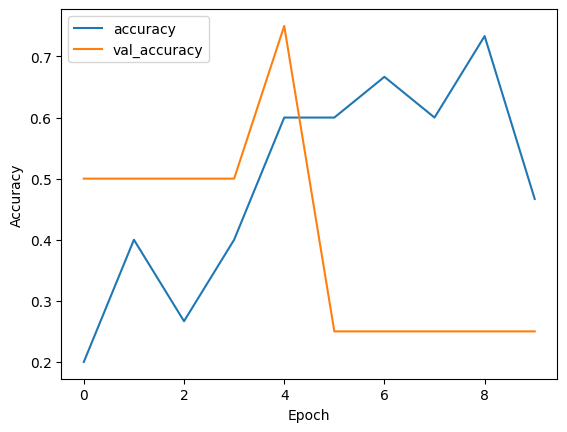

In [32]:
%matplotlib inline

# plot history
plt.figure()
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Run model over test data

After training the model, we have to run it over the test set and submit the results.

In [26]:
# load test data
test_path = f"{input_path}/data/test"
test_poses = []
ids = sorted([int(id.split(".")[0]) for id in os.listdir(f"{test_path}/poses")])
for id in ids:
    pose = np.load(f"{test_path}/poses/{id}.npy")
    test_poses.append(pose)
print(f"Dataset contains {len(test_poses)} samples for testing.")

Dataset contains 6 samples for testing.


In [27]:
# get results for test data
padded_test_poses = [
    np.pad(p, ((0, max_frames - p.shape[0]), (0, 0), (0, 0))) for p in test_poses
]
x_test_array = np.array(padded_test_poses)
y_pred = model.predict(x_test_array)
y_pred_array = np.argmax(y_pred, axis=1) + 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [28]:
len(y_pred_array)

6

In [29]:
# Store predictions in a CSV file to submit to the competition
pd.DataFrame({"ID": ids, "Label": y_pred_array}).to_csv("submission.csv", index=False)

In [30]:
# First, let's get the 0-indexed predictions from the model
y_pred_0_indexed = np.argmax(y_pred, axis=1)

# Now, use inverse_transform to get the original text labels
predicted_text_labels = label_encoder.inverse_transform(y_pred_0_indexed)

print("Original numerical predictions (0-indexed):", y_pred_0_indexed)
print("Predicted text labels:", predicted_text_labels)

Original numerical predictions (0-indexed): [0 0 0 0 0 0]
Predicted text labels: ['AGUA' 'AGUA' 'AGUA' 'AGUA' 'AGUA' 'AGUA']


If your competition submission requires the original text labels, you should modify the cell where you create the `submission.csv` file like this:

In [31]:
# Get 0-indexed predictions
y_pred_0_indexed = np.argmax(y_pred, axis=1)

# Convert numerical predictions back to text labels
predicted_text_labels_for_submission = label_encoder.inverse_transform(y_pred_0_indexed)

# Store predictions in a CSV file to submit to the competition with text labels
pd.DataFrame({"ID": ids, "Label": predicted_text_labels_for_submission}).to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' created with text labels.")

Submission file 'submission.csv' created with text labels.
